# The Mechanism of Learning

From the point of view of an observer, a learning is presented with input data that is paired with desired outputs. Once learning has occurred, that algorithm will be capable of producing correct outputs when it is fed new data that is **similar enough** to the input data it was trained on.

One interesting way to look at the learning problem is to look at it through the lens of parameter estimation.  
Let's show it using linear model example:

In [1]:
import torch

In [2]:
t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

In [3]:
import seaborn as sb

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='None', ylabel='None'>

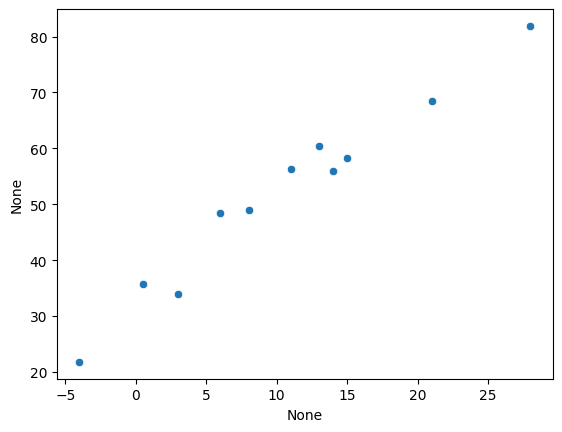

In [4]:
sb.scatterplot(x=t_c, y=t_u)

We have a model with some unknown parameters, and we need to estimate those parameters so that the error between predicted outputs and measured values is as low as possible. We notice that we still need to exactly define a measure of the error. Such a measure, which we refer to as the **loss function**, should be high if the error is high and should ideally be as low as possible for a perfect match.

A *loss function* (or cost function) is a function that computes a single numerical value that the learning process will attempt to minimize. We need a loos function to be convex.

In [5]:
# Define a linear model.
def model(t_u, w, b):
    return w * t_u + b

In [6]:
# Define a smooth, convex loss function
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

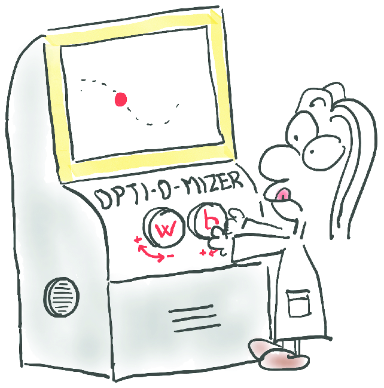


In [7]:
# For example, I guess random values for w and b and check the loss:
w = 0.12
b = 5.3
pred = model(t_u, w, b)
loss = loss_fn(pred, t_c)
print(loss)

tensor(48.6975)


# PyTorch’s autograd

PyTorch tensors can remember where they come from, in terms of the operations and parent tensors that originated them, and they can automatically provide the chain of derivatives of such operations with respect to their inputs.  PyTorch will automatically provide the gradient of that expression with respect to its input parameters.

In [22]:
params = torch.tensor([1.0, 0.0], requires_grad=True)

`requires_grad=True` tells PyTorch to track the entire family tree of tensors resulting from operations on `params`. In other words, any tensor that will have `params` as an ancestor will **have access to the chain of functions that were called to get from `params` to that tensor**. The value of the derivative will be automatically populated as a grad attribute of the `params` tensor.

In [23]:
params.grad is None

True

All we have to do to populate it is to start with a tensor with requires_grad set to True, then call the model and compute the loss, and finally call backward on the loss tensor:

In [15]:
loss = loss_fn(model(t_u, *params), t_c)

In [16]:
loss

tensor(1763.8846, grad_fn=<MeanBackward0>)

In [19]:
loss.backward()

In [20]:
params.grad

tensor([4517.2964,   82.6000])

At this point, the grad attribute of params contains the derivatives of the loss with respect to each element of params. 

How does it work? When we compute our loss while the parameters w and b require gradients, in addition to performing the actual computation, PyTorch creates what’s called a computation graph.
When we call loss.backward(), PyTorch traverses this graph in the reverse direction to compute the gradients, as shown by the arrows in the bottom row of the figure.

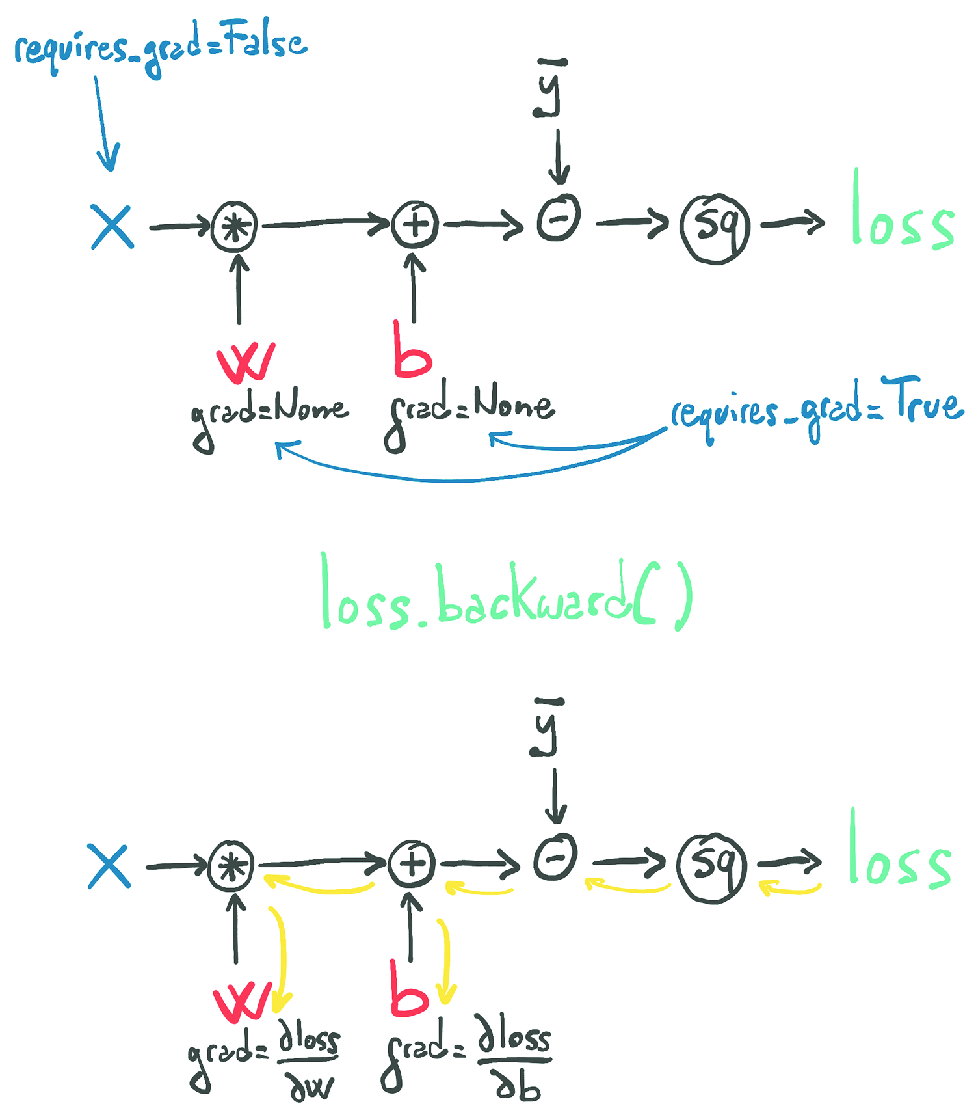


<div class="alert alert-block alert-warning">
    <b>Warning:</b> Calling backward will lead derivatives to accumulate at leaf nodes. We need to zero the gradient explicitly after using it for parameter updates.
</div>

To prevent this problem from occurring, we need to zero the gradient explicitly at each iteration. 

```python
if params.grad is not None:
    params.grad.zero_()
```

In [30]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:
            params.grad.zero_()

        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()

        # autograd tracking is disabled for the parameter update, so it’s safe to modify the params tensor in place
        with torch.no_grad():
            params -= learning_rate * params.grad

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))

    return params

In [31]:
t_un = 0.1 * t_u

In [32]:
training_loop(
    n_epochs = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1.0, 0.0], requires_grad=True),
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 7.860118
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957697
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927831
Epoch 4000, Loss 2.927680
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

⬆️⬆️⬆️ we used vanilla gradient descent for optimization, which worked fine for our simple case.

## Optimizers

Several optimization strategies and tricks can assist convergence, especially when models get complicated.

In [33]:
import torch.optim as optim

In [34]:
dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 'lr_scheduler',
 'swa_utils']

Let's rewrite what we have written already with a simplest ready-made optimizer.

In [41]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

In [42]:
t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
loss.backward()
optimizer.step()

print(params)

tensor([ 9.9999e-01, -1.0000e-05], requires_grad=True)


The optimizer looks into `params.grad` and updates `params`, subtracting `learning_rate` times `grad` from it, exactly as in our former hand-rolled code.

```
[Input]
   |
   v
[Forward pass]
make predictions
   |
   v
[Loss]
compare predictions
with true answers
   |
   v
[Backward pass]
compute gradients
   |
   v
[Optimizer step]
adjust weights
   |
   v
[Repeat]
```

In [43]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)  # Step 1: compute predictions based on the model at hand
        loss = loss_fn(t_p, t_c)   # Step 2: Compute the loss function. Since "params" are 
                                   #   initialized with requires_grad=True, we will track gradients all the way back
        optimizer.zero_grad()  # required!
        loss.backward()           # Step 3: Backpropagation step: apply chain rule to find direction for params nudging 
        optimizer.step()          # Step 4: Update (nudge) params a bit to lower the loss

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
    return params

In [45]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)  # Use different optimizer.

training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    params = params,                                
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 2.962301
Epoch 1000, Loss 2.927645
Epoch 1500, Loss 2.927645
Epoch 2000, Loss 2.927646
Epoch 2500, Loss 2.927646
Epoch 3000, Loss 2.927644
Epoch 3500, Loss 2.927646
Epoch 4000, Loss 2.927646
Epoch 4500, Loss 2.927645
Epoch 5000, Loss 2.927645


tensor([  5.3677, -17.3048], requires_grad=True)

(A) Conceptual representation of how an optimizer holds a reference to parameters. (B) After a loss is computed from inputs, (C) a call to .backward leads to .grad being populated on parameters. (D) At that point, the optimizer can access .grad and compute the parameter updates.

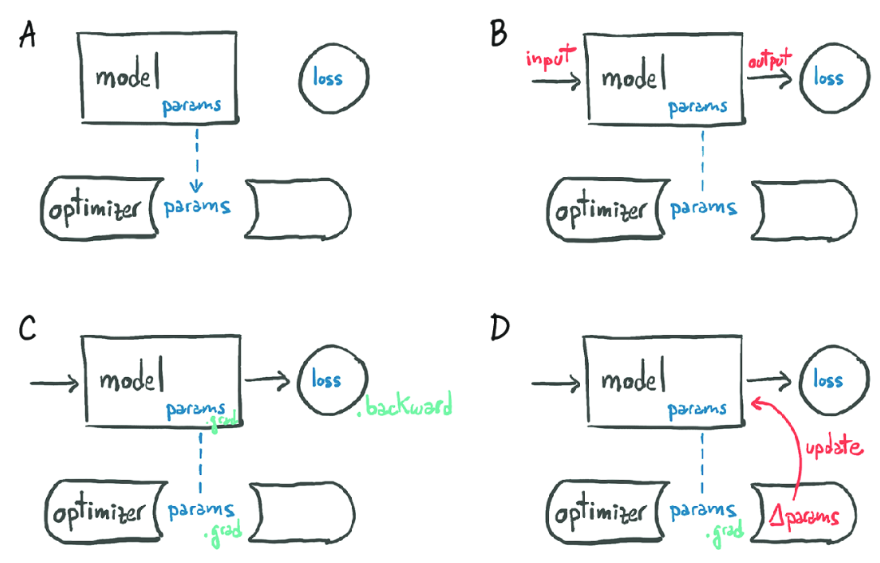


## Autograd nits and switching it off

When we already have a split of our data into training set and validation set, we can observe validation set loss while training:

In [55]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u,
                  train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        with torch.no_grad():
            val_t_p = model(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False

        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")

    return params

Errors will only ever backpropagate based on the training set—the validation set is used to provide an independent evaluation of the accuracy of the model’s output on data that wasn’t used for training.

We will effectively have two computational graphs - one for `train_loss` and one for `val_loss`. Since we don't call `.backward()` on `val_loss`, we will not update gradients in shared `params` tensor - it will remain affected only by `train_loss`. 

# Example: Different Model

Let's use a slightly different model:

In [56]:
def model(t_u, w1, w2, b):
    return w2 * t_u ** 2 + w1 * t_u + b

I can use pretty much the same code, with just a single adjustment to parameters seed:

In [57]:
params = torch.tensor([1.0, 1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.Adam([params], lr=learning_rate)

In [58]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]
train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

In [59]:
training_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un,
    val_t_u = val_t_un,
    train_t_c = train_t_c,
    val_t_c = val_t_c
)

Epoch 1, Training loss 674.0505, Validation loss 683.6412
Epoch 2, Training loss 653.2509, Validation loss 664.4142
Epoch 3, Training loss 632.7903, Validation loss 645.4707
Epoch 500, Training loss 6.0688, Validation loss 6.5259
Epoch 1000, Training loss 3.9252, Validation loss 4.2332
Epoch 1500, Training loss 3.2323, Validation loss 3.0461
Epoch 2000, Training loss 3.0656, Validation loss 2.6517
Epoch 2500, Training loss 2.9639, Validation loss 2.6213
Epoch 3000, Training loss 2.8470, Validation loss 2.7189


tensor([ 1.1105e-03,  5.0969e-01, -4.1333e+00], requires_grad=True)